In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('CO2 Emissions_Canada.csv')

In [3]:
df.drop(['Make', 'Model', 'Vehicle Class', 'Transmission'], axis=1, errors='ignore', inplace=True)

In [4]:
df_encoded = pd.get_dummies(df, columns=['Fuel Type'], prefix='', prefix_sep='', drop_first=True)
df_encoded = df_encoded.astype(int)

In [5]:
X = df_encoded[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'E', 'N', 'X',
       'Z']]
y = df_encoded['Legal Limit'].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)
# Make predictions on test set
y_pred = clf.predict(X_test)

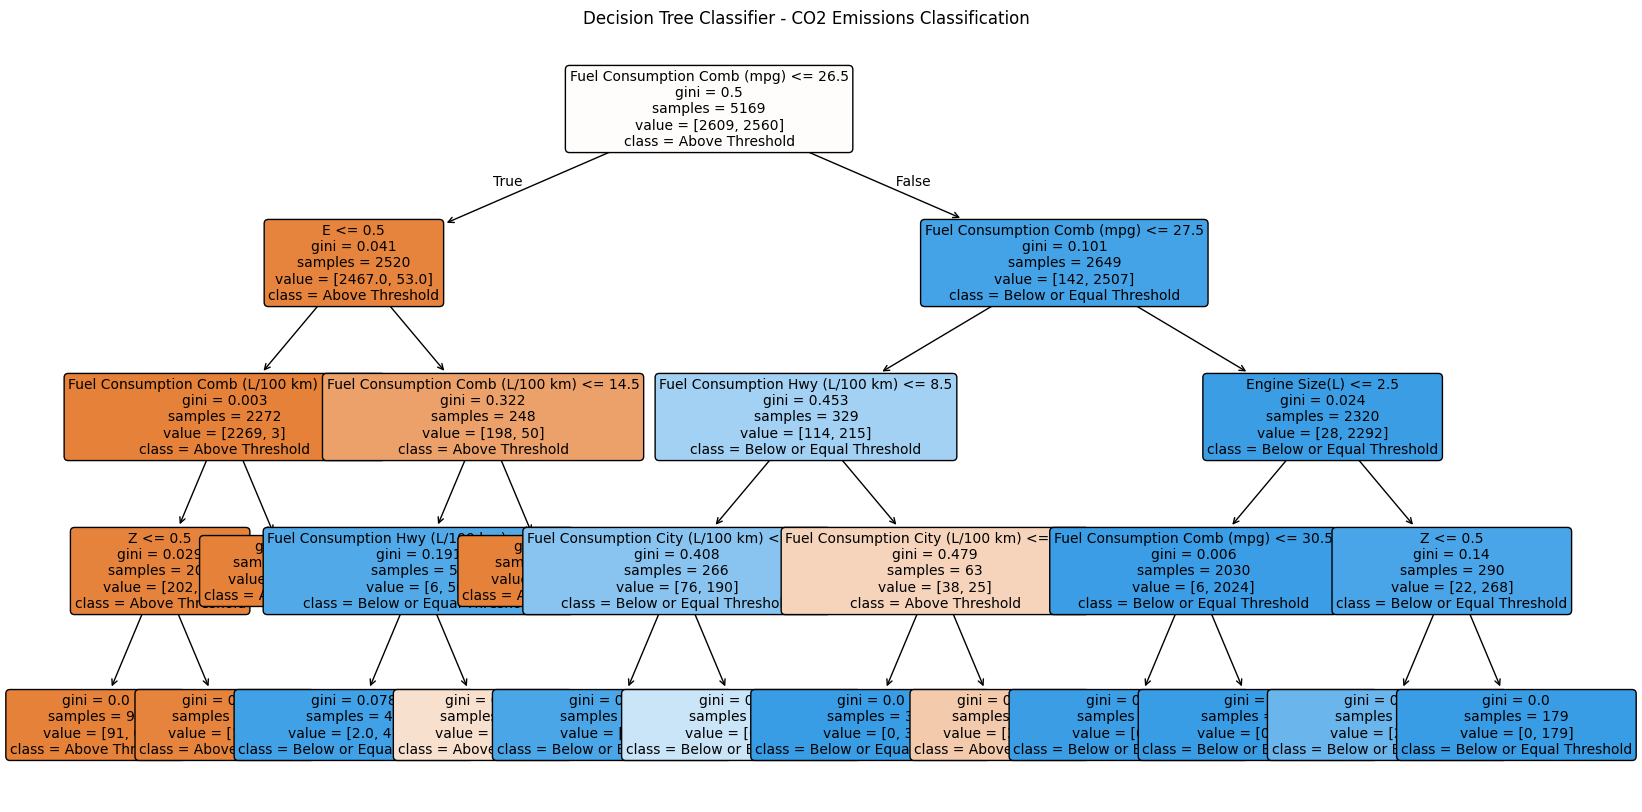

In [8]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Above Threshold', 'Below or Equal Threshold'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Classifier - CO2 Emissions Classification')
plt.show()

In [10]:
from sklearn.metrics import accuracy_score, precision_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

<class 'NameError'>: name 'recall_score' is not defined